In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_ribbon import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx

def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class Example(TripletModel):
    # unconstrained trainable parameters for 2x2 lower-triangular factor
    K: jax.Array

    def __init__(self, der_K: jax.Array, key: jax.Array):
        """
        der_K is the user-facing physical 3-vector:
            [k_ss, k_sb, k_bb]

        We convert it to unconstrained parameters of a Cholesky factor L
        so that the induced 2x2 matrix B = L L^T is always symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        print("Initializing with physical parameters: ", der_K)

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD condition for
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert physical coefficients to Cholesky factor entries
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries(self) -> jax.Array:
        """
        Returns the physical coefficients [k_ss, k_sb, k_bb], guaranteed PSD.
        """
        L = self._vec_to_L(self.K)
        B = L @ L.T

        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]
        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self) -> jax.Array:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries()
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries()

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
# train_datafile = "experiment_data/train_from_experiment.npz"
# valid_datafile = "experiment_data/train_from_experiment.npz"

train_datafile = "ribbon/train_direct_bc.npz"
valid_datafile = "ribbon/train_direct_bc.npz"

init_K=jnp.array([0.03, 0.0001, 0.000005])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=200, lr=1e-3, init_K=init_K )
# final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=100, lr=1e-2, init_K=None )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Initializing with physical parameters:  [3.e-02 1.e-04 5.e-06]
lk:  0.005000000000000001
EA:  2.000000000000001
EI1:  0.006666666666666665
EI2:  2.666666666666667
GJ:  0.004444444444444444
Initializing with physical parameters:  [3.e-02 1.e-04 5.e-06]
Initial training loss: 2.05284e-06
K: [-1.66543301e+00  8.16496581e-04 -6.17402673e+00]
grad K: [-6.01258544e-08 -9.56562537e-05 -5.79737963e-07]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-03  | Train: 2.05284e-06  | Valid: 1.91284e-06  | K: [-1.66457561e+00  1.81639205e-03 -6.17304369e+00]
Step 10   | LR: 9.945e-04  | Train: 3.95868e-07  | Valid: 3.19427e-07  | K: [-1.65675017  0.01154899 -6.16483479]
Step 20   | LR: 9.782e-04  | Train: 1.12628e-07  | Valid: 1.13294e-07  | K: [-1.64986502  0.01827869 -6.16074512]
Step 30   | LR: 9.514e-04  | Train: 1.36954e-07  | Valid: 1.38512e-07  | K: [-1.64259347  0.0207151  -6.15897125]
Step 40   | LR: 9.149e-04  | Train: 1.37136e-07  | Valid: 1.35792e-07  | K: [-1.63500941  0.020568

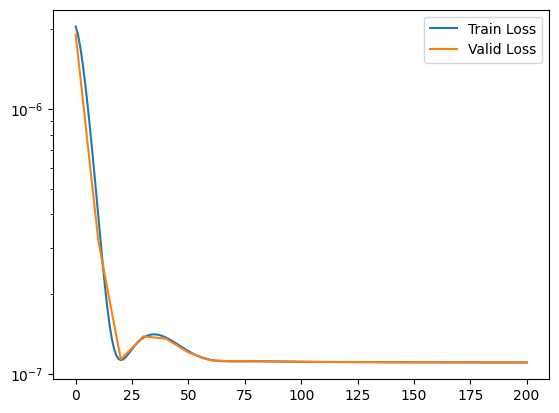

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (1, 101, 32)
lk:  0.005000000000000001
EA:  2.000000000000001
EI1:  0.006666666666666665
EI2:  2.666666666666667
GJ:  0.004444444444444444
xb.shape (1, 101, 32)
pred.shape (1, 101, 83)
valid.qs.shape (1, 101, 83)
train.qs.shape (1, 101, 83)


In [9]:
# animate(valid.qs)

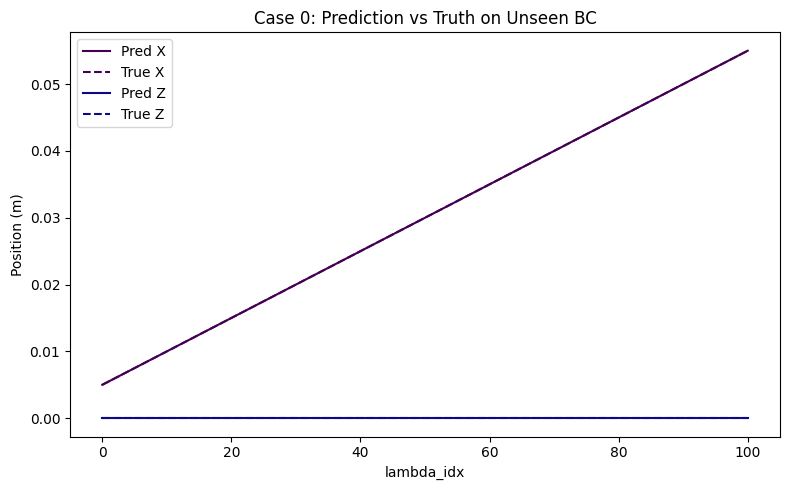

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.004       0.          0.          0.          0.009       0.
   0.          0.          0.01394714 -0.         -0.00071467  0.
   0.01877164  0.         -0.002022    0.          0.02346209  0.
  -0.00374968  0.          0.02806348  0.         -0.00570227  0.
   0.03265453  0.         -0.00767902  0.          0.03731596  0.
  -0.00948351  0.          0.0420998   0.         -0.01093247  0.
   0.04700942  0.         -0.01187051  0.          0.05199751  0.
  -0.01219122  0.          0.05698473  0.         -0.0118571   0.
   0.06189217  0.         -0.01090778  0.          0.06667379  0.
  -0.00945145  0.          0.07133433  0.         -0.00764465  0.
   0.07592668  0.         -0.00567087  0.          0.0805312   0.
  -0.00372565  0.          0.08522524  0.         -0.00200774  0.
   0.09005219  0.         -0.00070952  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0045      0.          0.          0.          0.0095  

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01197081 -0.         -0.00052669  0.
   0.01687808  0.         -0.00147825  0.          0.02171886  0.
  -0.00272479  0.          0.02651826  0.         -0.00412228  0.
   0.03131642  0.         -0.00552397  0.          0.0361522   0.
  -0.00678975  0.          0.04104874  0.         -0.007795    0.
   0.04600556  0.         -0.00844032  0.          0.05099929  0.
  -0.00866136  0.          0.05599284  0.         -0.00843603  0.
   0.06094921  0.         -0.00778722  0.          0.06584534  0.
  -0.00677993  0.          0.07068106  0.         -0.00551386  0.
   0.07547964  0.         -0.00411355  0.          0.08027979  0.
  -0.00271861  0.          0.08512133  0.         -0.00147492  0.
   0.09002905  0.         -0.00052562  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0.   

In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01197081 -0.         -0.00052669  0.
   0.01687808  0.         -0.00147825  0.          0.02171886  0.
  -0.00272479  0.          0.02651826  0.         -0.00412228  0.
   0.03131642  0.         -0.00552397  0.          0.0361522   0.
  -0.00678975  0.          0.04104874  0.         -0.007795    0.
   0.04600556  0.         -0.00844032  0.          0.05099929  0.
  -0.00866136  0.          0.05599284  0.         -0.00843603  0.
   0.06094921  0.         -0.00778722  0.          0.06584534  0.
  -0.00677993  0.          0.07068106  0.         -0.00551386  0.
   0.07547964  0.         -0.00411355  0.          0.08027979  0.
  -0.00271861  0.          0.08512133  0.         -0.00147492  0.
   0.09002905  0.         -0.00052562  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0. 

In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.002       0.          0.          0.          0.007       0.
   0.          0.          0.01199756  0.         -0.00074365  0.
   0.01683965  0.         -0.00212275  0.          0.02159604  0.
  -0.0036933   0.          0.02637043  0.         -0.00515622  0.
   0.03120566  0.         -0.00637895  0.          0.03610147  0.
  -0.00732425  0.          0.04104316  0.         -0.00799199  0.
   0.0460144   0.         -0.00838943  0.          0.051       0.
  -0.00852143  0.          0.0559856   0.         -0.00838943  0.
   0.06095684  0.         -0.00799199  0.          0.06589853  0.
  -0.00732425  0.          0.07079434  0.         -0.00637895  0.
   0.07562957  0.         -0.00515622  0.          0.08040396  0.
  -0.0036933   0.          0.08516035  0.         -0.00212275  0.
   0.09000244  0.         -0.00074365  0.          0.095       0.
   0.          0.          0.1         0.          0.        ]
 [ 0.0025      0.      